# **FINAL PROJECT (us regions)**

In [12]:
## helpful packages
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import random
import re
import string

## Install relevant packages if you haven't already
## ! conda activate qss20
## ! conda install nltk spacy vaderSentiment gensim scikit-learn "scipy<1.13"

## nltk imports
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords

## spacy imports
import spacy
### uncomment and run the below line if you haven't loaded the en_core_web_sm library yet
## ! python -m spacy download en_core_web_sm
import en_core_web_sm
nlp = en_core_web_sm.load()

## vectorizer
from sklearn.feature_extraction.text import CountVectorizer

## sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## LDA
from gensim import corpora
import gensim

## repeated printouts and wide-format text
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_colwidth', None)

## **TWEETS**

In [13]:
## The Climate Change Twitter Dataset
## insert link

tweets = pd.read_csv("The Climate Change Twitter Dataset.csv") 

# Preview
tweets.head()
tweets.tail(10)

# Check column info
tweets.info()

# Missing data
tweets.isnull().sum() ## 7309504 missing values 

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness
0,2006-06-06 16:06:42+00:00,6132,NaN,NaN,Weather Extremes,-0.097180,neutral,female,NaN,aggressive
1,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive
2,2006-08-29 01:52:30+00:00,23160,NaN,NaN,Weather Extremes,0.500479,neutral,male,NaN,aggressive
3,2006-11-07 02:46:52+00:00,57868,NaN,NaN,Weather Extremes,0.032816,neutral,male,NaN,aggressive
4,2006-11-27 14:27:43+00:00,304553,NaN,NaN,Importance of Human Intervantion,-0.090428,neutral,male,NaN,aggressive


,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness
11012363,2018-09-02 08:02:48+00:00,1036162510611730432,NaN,NaN,Undefined / One Word Hashtags,-0.112085,believer,male,NaN,not aggressive
11012364,2018-09-02 08:02:52+00:00,1036162527078633473,NaN,NaN,Global stance,0.107227,believer,male,NaN,aggressive
11012365,2018-09-02 08:02:58+00:00,1036162552127008768,NaN,NaN,Importance of Human Intervantion,0.634885,believer,female,NaN,not aggressive
11012366,2018-09-02 08:03:17+00:00,1036162635606241285,13.410530,52.524370,Undefined / One Word Hashtags,-0.393662,believer,female,8.326254,not aggressive
11012367,2018-09-02 08:03:19+00:00,1036162643751567360,-0.243930,51.451650,Weather Extremes,0.514416,believer,male,4.063849,not aggressive
11012368,2018-09-02 08:03:21+00:00,1036162652400173056,NaN,NaN,Weather Extremes,-0.509263,believer,female,NaN,not aggressive
11012369,2018-09-02 08:03:28+00:00,1036162678253932544,NaN,NaN,Global stance,-0.522887,believer,male,NaN,aggressive
11012370,2018-09-02 08:03:37+00:00,1036162717327998976,NaN,NaN,Undefined / One Word Hashtags,-0.060764,believer,male,NaN,not aggressive
11012371,2018-09-02 08:03:48+00:00,1036162762802642944,32.535650,15.593325,Global stance,0.616264,believer,male,-2.634107,not aggressive
11012372,2018-09-02 08:03:49+00:00,1036162767735218176,-82.669508,27.770380,Global stance,0.140839,neutral,female,0.217859,not


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11012373 entries, 0 to 11012372
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 840.2+ MB


created_at               0
id                       0
lng                7309504
lat                7309504
topic                    0
sentiment                0
stance                   0
gender                   0
temperature_avg    7309504
aggressiveness           0
dtype: int64

In [75]:
# keep a copy, add in countries later
## tweets_clean = tweets.copy()

# make sure lat/lng are numeric
tweets['lat'] = pd.to_numeric(tweets['lat'], errors='coerce')
tweets['lng'] = pd.to_numeric(tweets['lng'], errors='coerce')

# drop rows with missing coords
tweets = tweets.dropna(subset=['lat', 'lng'])

# keep only realistic coords
tweets = tweets[
    (tweets['lat'] >= -90) & (tweets['lat'] <= 90) &
    (tweets['lng'] >= -180) & (tweets['lng'] <= 180)]

In [76]:
import reverse_geocoder as rg

# build list of (lat, lon) tuples
coords = list(zip(tweets['lat'], tweets['lng']))

# reverse_geocoder can take a list directly
results = rg.search(coords)   # returns list of dicts

In [77]:
countries = [r['cc'] for r in results]
tweets = tweets.reset_index(drop=True)
tweets['country'] = countries
print(tweets['country']) ## 3702869, but these are abbreviations not the country's name
tweets.info()

0          US
1          US
2          US
3          US
4          GB
           ..
3702864    TR
3702865    DE
3702866    GB
3702867    SD
3702868    US
Name: country, Length: 3702869, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702869 entries, 0 to 3702868
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
 10  country          object 
dtypes: float64(4), int64(1), object(6)
memory usage: 310.8+ MB


In [78]:
tweets_us = tweets[tweets['country'] == 'US'].copy()
tweets_us.shape
tweets_us.head()
tweets_us['country'].value_counts()

(2097940, 11)

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness,country
0,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,US
1,2006-12-14 01:39:10+00:00,1092823,-122.419420,37.774930,Ideological Positions on Global Warming,-0.544195,neutral,male,4.228540,aggressive,US
2,2006-12-17 19:43:09+00:00,1278023,-79.791980,36.072640,Weather Extremes,-0.565028,denier,male,5.478175,aggressive,US
3,2006-12-21 01:39:01+00:00,1455543,-121.805790,38.004920,Weather Extremes,0.650960,neutral,male,-1.652156,not aggressive,US
5,2007-01-06 17:36:51+00:00,2266613,-73.949582,40.650104,Weather Extremes,-0.567821,neutral,male,15.600876,aggressive,US


country
US    2097940
Name: count, dtype: int64

In [79]:
## LAT/LONG -> STATES/REGIONS

# extract admin1 (state name)
states = [r['admin1'] for r in results]

# add to tweets dataframe BEFORE filtering for US
tweets['state_name'] = states

# now rebuild US-only tweets with state included
tweets_us = tweets[tweets['country'] == 'US'].copy()

tweets_us[['lat','lng','state_name']].head()
tweets_us.head()

,lat,lng,state_name
0,40.650104,-73.949582,New York
1,37.774930,-122.419420,California
2,36.072640,-79.791980,North Carolina
3,38.004920,-121.805790,California
5,40.650104,-73.949582,New York


,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness,country,state_name
0,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,US,New York
1,2006-12-14 01:39:10+00:00,1092823,-122.419420,37.774930,Ideological Positions on Global Warming,-0.544195,neutral,male,4.228540,aggressive,US,California
2,2006-12-17 19:43:09+00:00,1278023,-79.791980,36.072640,Weather Extremes,-0.565028,denier,male,5.478175,aggressive,US,North Carolina
3,2006-12-21 01:39:01+00:00,1455543,-121.805790,38.004920,Weather Extremes,0.650960,neutral,male,-1.652156,not aggressive,US,California
5,2007-01-06 17:36:51+00:00,2266613,-73.949582,40.650104,Weather Extremes,-0.567821,neutral,male,15.600876,aggressive,US,New York


In [80]:
state_to_region = {
    # Northeast
    'Connecticut':'Northeast','Maine':'Northeast','Massachusetts':'Northeast',
    'New Hampshire':'Northeast','Rhode Island':'Northeast','Vermont':'Northeast',
    'New Jersey':'Northeast','New York':'Northeast','Pennsylvania':'Northeast',

    # Midwest
    'Illinois':'Midwest','Indiana':'Midwest','Michigan':'Midwest','Ohio':'Midwest',
    'Wisconsin':'Midwest','Iowa':'Midwest','Kansas':'Midwest','Minnesota':'Midwest',
    'Missouri':'Midwest','Nebraska':'Midwest','North Dakota':'Midwest','South Dakota':'Midwest',

    # South
    'Delaware':'South','Florida':'South','Georgia':'South','Maryland':'South',
    'North Carolina':'South','South Carolina':'South','Virginia':'South','District of Columbia':'South',
    'West Virginia':'South','Alabama':'South','Kentucky':'South','Mississippi':'South','Tennessee':'South',
    'Arkansas':'South','Louisiana':'South','Oklahoma':'South','Texas':'South',

    # West
    'Arizona':'West','Colorado':'West','Idaho':'West','Montana':'West','Nevada':'West',
    'New Mexico':'West','Utah':'West','Wyoming':'West','Alaska':'West','California':'West',
    'Hawaii':'West','Oregon':'West','Washington':'West'
}

tweets_us['region'] = tweets_us['state_name'].map(state_to_region)


In [81]:
tweets_us['state_name'].value_counts()
tweets_us['region'].value_counts()
tweets_us[['lat','lng','state_name','region']].head()
tweets_us.info()

state_name
California          334443
New York            191489
Texas               136259
Florida             130722
Washington, D.C.    125569
Massachusetts        78205
Pennsylvania         69489
Illinois             67654
Washington           60238
Oregon               52374
Ohio                 49050
North Carolina       44397
Tennessee            43799
Colorado             43671
New Jersey           43448
Georgia              42322
Michigan             42093
Arizona              41717
Minnesota            40454
Maryland             38792
Virginia             35027
Missouri             31003
Wisconsin            27869
Indiana              22011
Kentucky             21676
Nevada               19689
Connecticut          19291
South Carolina       16438
New Hampshire        15884
Iowa                 15744
Utah                 15465
Louisiana            15226
Alabama              14904
Oklahoma             14438
New Mexico           12959
West Virginia        12611
Maine            

region
West         620911
South        583915
Northeast    446503
Midwest      321042
Name: count, dtype: int64

,lat,lng,state_name,region
0,40.650104,-73.949582,New York,Northeast
1,37.774930,-122.419420,California,West
2,36.072640,-79.791980,North Carolina,South
3,38.004920,-121.805790,California,West
5,40.650104,-73.949582,New York,Northeast


<class 'pandas.core.frame.DataFrame'>
Index: 2097940 entries, 0 to 3702868
Data columns (total 13 columns):
 #   Column           Dtype  
---  ------           -----  
 0   created_at       object 
 1   id               int64  
 2   lng              float64
 3   lat              float64
 4   topic            object 
 5   sentiment        float64
 6   stance           object 
 7   gender           object 
 8   temperature_avg  float64
 9   aggressiveness   object 
 10  country          object 
 11  state_name       object 
 12  region           object 
dtypes: float64(4), int64(1), object(8)
memory usage: 224.1+ MB


In [82]:
## created_at -> year & month 

tweets_us['created_at'].head()

tweets_us['created_at'] = pd.to_datetime(
    tweets_us['created_at'], 
    errors='coerce', 
    utc=True  # keep timezone-safe
)

tweets_us['created_at'] ## there's nothing after 2018 

tweets_us['year'] = tweets_us['created_at'].dt.year
tweets_us['month'] = tweets_us['created_at'].dt.month
tweets_us[['year', 'month']] ## july 2006 to september 2018 
tweets_us.info()

0    2006-07-23 21:52:30+00:00
1    2006-12-14 01:39:10+00:00
2    2006-12-17 19:43:09+00:00
3    2006-12-21 01:39:01+00:00
5    2007-01-06 17:36:51+00:00
Name: created_at, dtype: object

0         2006-07-23 21:52:30+00:00
1         2006-12-14 01:39:10+00:00
2         2006-12-17 19:43:09+00:00
3         2006-12-21 01:39:01+00:00
5         2007-01-06 17:36:51+00:00
                     ...           
3702842   2018-09-02 07:57:01+00:00
3702854   2018-09-02 08:00:08+00:00
3702856   2018-09-02 08:00:39+00:00
3702863   2018-09-02 08:02:31+00:00
3702868   2018-09-02 08:03:49+00:00
Name: created_at, Length: 2097940, dtype: datetime64[ns, UTC]

,year,month
0,2006,7
1,2006,12
2,2006,12
3,2006,12
5,2007,1
...,...,...
3702842,2018,9
3702854,2018,9
3702856,2018,9
3702863,2018,9


<class 'pandas.core.frame.DataFrame'>
Index: 2097940 entries, 0 to 3702868
Data columns (total 15 columns):
 #   Column           Dtype              
---  ------           -----              
 0   created_at       datetime64[ns, UTC]
 1   id               int64              
 2   lng              float64            
 3   lat              float64            
 4   topic            object             
 5   sentiment        float64            
 6   stance           object             
 7   gender           object             
 8   temperature_avg  float64            
 9   aggressiveness   object             
 10  country          object             
 11  state_name       object             
 12  region           object             
 13  year             int32              
 14  month            int32              
dtypes: datetime64[ns, UTC](1), float64(4), int32(2), int64(1), object(7)
memory usage: 240.1+ MB


## **DISASTERS**

In [83]:
disasters = pd.read_csv("disasters.csv")  # replace filename
disasters.head() 
disasters.info() ## 4913 rows, 17 columns 

,Disaster Type,Disaster Subtype,Disaster Group,Disaster Subgroup,Event Name,Origin,Country,Location,Latitude,Longitude,start_date,end_date,Total Deaths,No Affected,Reconstruction Costs ('000 US$),Total Damages ('000 US$),CPI
0,Earthquake,Ground movement,Natural,Geophysical,NaN,NaN,Japan,"Nanao, Wajima districts (Isikawa province), Niigata, Toyama provinces",37.336,136.588,2007-03-25,2007-03-25,1.0,NaN,NaN,250000.0,81.101659
1,Storm,Tropical cyclone,Natural,Meteorological,Indhala,NaN,Madagascar,"Diana, Sava, Sofia, Analanjirofo provinces",-14.840,49.940,2007-03-15,2007-03-17,80.0,203182.0,NaN,240000.0,81.101659
2,Flood,Flash flood,Natural,Hydrological,NaN,Storms and heavy rains,Australia,"Gosford, Dungog, Newcastle, Wyong, Port Stephens, Maitland, Cessnock districts (New South Wales province)",-32.870,151.380,2007-06-08,2007-06-12,9.0,5000.0,NaN,1300000.0,81.101659
3,Flood,Riverine flood,Natural,Hydrological,NaN,Heavy rains,Haiti,"Ferrier village (Fort Liberte district, Nord Est province), Ouanaminthe district (Nord Est province), Abricot village (Jeremie district, Grande Anse province)",19.410,-71.780,2007-03-26,2007-03-30,14.0,15000.0,NaN,NaN,81.101659
4,Flood,Riverine flood,Natural,Hydrological,NaN,Heavy rains,Argentina,"Tucuman, Santiago del Estero, Salta, Formosa provinces",NaN,NaN,2007-01-18,2007-03-20,5.0,60000.0,NaN,30000.0,81.101659


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Disaster Type                    4913 non-null   object 
 1   Disaster Subtype                 4212 non-null   object 
 2   Disaster Group                   4913 non-null   object 
 3   Disaster Subgroup                4913 non-null   object 
 4   Event Name                       979 non-null    object 
 5   Origin                           2067 non-null   object 
 6   Country                          4913 non-null   object 
 7   Location                         4787 non-null   object 
 8   Latitude                         1290 non-null   float64
 9   Longitude                        1294 non-null   float64
 10  start_date                       4913 non-null   object 
 11  end_date                         4913 non-null   object 
 12  Total Deaths        

In [84]:
disasters['start_date'] = pd.to_datetime(disasters['start_date'], errors='coerce')
disasters['end_date'] = pd.to_datetime(disasters['end_date'], errors='coerce')

## Extract the year from start_date (main time variable)
disasters['year'] = disasters['start_date'].dt.year
disasters['month'] = disasters['start_date'].dt.month

disasters[['year', 'month']] ## march 2007 to july 2020 
disasters.info()

,year,month
0,2007,3
1,2007,3
2,2007,6
3,2007,3
4,2007,1
...,...,...
4908,2020,4
4909,2020,1
4910,2020,3
4911,2020,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Disaster Type                    4913 non-null   object        
 1   Disaster Subtype                 4212 non-null   object        
 2   Disaster Group                   4913 non-null   object        
 3   Disaster Subgroup                4913 non-null   object        
 4   Event Name                       979 non-null    object        
 5   Origin                           2067 non-null   object        
 6   Country                          4913 non-null   object        
 7   Location                         4787 non-null   object        
 8   Latitude                         1290 non-null   float64       
 9   Longitude                        1294 non-null   float64       
 10  start_date                       4913 non-null   datetime64[

In [85]:
us_disasters = disasters[disasters['Country'] == 'United States of America (the)'].copy()
us_disasters.shape
us_disasters.head()

(312, 19)

,Disaster Type,Disaster Subtype,Disaster Group,Disaster Subgroup,Event Name,Origin,Country,Location,Latitude,Longitude,start_date,end_date,Total Deaths,No Affected,Reconstruction Costs ('000 US$),Total Damages ('000 US$),CPI,year,month
52,Storm,NaN,Natural,Meteorological,NaN,NaN,United States of America (the),"California, Texas, Georgia, South Carolina, Oklahoma, Missouri, Iowa, Michigan, New York, Maine, Kansas, Illinois provinces",NaN,NaN,2007-01-12,2007-01-17,65.0,NaN,NaN,500000.0,81.101659,2007,1
67,Storm,Convective storm,Natural,Meteorological,NaN,NaN,United States of America (the),"New York, Vermont, New Jersey, Ohio, Pennsylvania provinces",NaN,NaN,2007-02-14,2007-02-15,16.0,NaN,NaN,140000.0,81.101659,2007,2
68,Storm,Convective storm,Natural,Meteorological,NaN,NaN,United States of America (the),Texas province,NaN,NaN,2007-04-24,2007-04-26,10.0,NaN,NaN,NaN,81.101659,2007,4
92,Storm,Convective storm,Natural,Meteorological,NaN,NaN,United States of America (the),"Volusia, Lake, Sumter, Seminole districts (Florida province)",NaN,NaN,2007-02-02,2007-02-02,20.0,6600.0,NaN,130000.0,81.101659,2007,2
93,Storm,Convective storm,Natural,Meteorological,NaN,NaN,United States of America (the),"Alabama, Missouri, Georgia, Minnesota provinces",NaN,NaN,2007-03-01,2007-03-02,20.0,NaN,NaN,600000.0,81.101659,2007,3


In [86]:
'''

# start from the US-only disasters you already filtered
us_disasters = us_disasters.copy()

# how many rows to start?
print("Starting rows:", len(us_disasters))

# check missingness BEFORE coercion
print("Missing lat before numeric:", us_disasters['Latitude'].isna().sum())
print("Missing lon before numeric:", us_disasters['Longitude'].isna().sum())

# coerce to numeric but don't drop yet
us_disasters['Latitude_num']  = pd.to_numeric(us_disasters['Latitude'], errors='coerce')
us_disasters['Longitude_num'] = pd.to_numeric(us_disasters['Longitude'], errors='coerce')

print("Missing lat after numeric:", us_disasters['Latitude_num'].isna().sum())
print("Missing lon after numeric:", us_disasters['Longitude_num'].isna().sum())

# how many rows have BOTH coords usable?
mask_coords = us_disasters['Latitude_num'].notna() & us_disasters['Longitude_num'].notna()
print("Rows with usable coords:", mask_coords.sum())

# see a few that failed numeric conversion
us_disasters.loc[~mask_coords, ['Latitude','Longitude']].head(10)

'''

'\n\n# start from the US-only disasters you already filtered\nus_disasters = us_disasters.copy()\n\n# how many rows to start?\nprint("Starting rows:", len(us_disasters))\n\n# check missingness BEFORE coercion\nprint("Missing lat before numeric:", us_disasters[\'Latitude\'].isna().sum())\nprint("Missing lon before numeric:", us_disasters[\'Longitude\'].isna().sum())\n\n# coerce to numeric but don\'t drop yet\nus_disasters[\'Latitude_num\']  = pd.to_numeric(us_disasters[\'Latitude\'], errors=\'coerce\')\nus_disasters[\'Longitude_num\'] = pd.to_numeric(us_disasters[\'Longitude\'], errors=\'coerce\')\n\nprint("Missing lat after numeric:", us_disasters[\'Latitude_num\'].isna().sum())\nprint("Missing lon after numeric:", us_disasters[\'Longitude_num\'].isna().sum())\n\n# how many rows have BOTH coords usable?\nmask_coords = us_disasters[\'Latitude_num\'].notna() & us_disasters[\'Longitude_num\'].notna()\nprint("Rows with usable coords:", mask_coords.sum())\n\n# see a few that failed numeric 

In [87]:
# Ensure correct numeric types
us_disasters['Latitude']  = pd.to_numeric(us_disasters['Latitude'], errors='coerce')
us_disasters['Longitude'] = pd.to_numeric(us_disasters['Longitude'], errors='coerce')

# Drop missing coords
us_disasters = us_disasters.dropna(subset=['Latitude', 'Longitude'])

# Keep valid ranges
us_disasters = us_disasters[
    (us_disasters['Latitude']  >= -90)  & (us_disasters['Latitude']  <= 90) &
    (us_disasters['Longitude'] >= -180) & (us_disasters['Longitude'] <= 180)
]

coords_disasters = list(zip(us_disasters['Latitude'], us_disasters['Longitude']))
len(coords_disasters)

39

In [88]:
results_dis = rg.search(coords_disasters, mode=1)

# Add state + country code
us_disasters['state_name']   = [r['admin1'] for r in results_dis]
us_disasters['country_code'] = [r['cc'] for r in results_dis]

In [89]:
us_disasters = us_disasters[us_disasters['country_code'] == 'US']
us_disasters['country_code'].value_counts()

country_code
US    38
Name: count, dtype: int64

In [90]:
state_to_region = {
    # Northeast
    'Connecticut':'Northeast','Maine':'Northeast','Massachusetts':'Northeast',
    'New Hampshire':'Northeast','Rhode Island':'Northeast','Vermont':'Northeast',
    'New Jersey':'Northeast','New York':'Northeast','Pennsylvania':'Northeast',

    # Midwest
    'Illinois':'Midwest','Indiana':'Midwest','Michigan':'Midwest','Ohio':'Midwest',
    'Wisconsin':'Midwest','Iowa':'Midwest','Kansas':'Midwest','Minnesota':'Midwest',
    'Missouri':'Midwest','Nebraska':'Midwest','North Dakota':'Midwest','South Dakota':'Midwest',

    # South
    'Delaware':'South','Florida':'South','Georgia':'South','Maryland':'South',
    'North Carolina':'South','South Carolina':'South','Virginia':'South','District of Columbia':'South',
    'West Virginia':'South','Alabama':'South','Kentucky':'South','Mississippi':'South','Tennessee':'South',
    'Arkansas':'South','Louisiana':'South','Oklahoma':'South','Texas':'South',

    # West
    'Arizona':'West','Colorado':'West','Idaho':'West','Montana':'West','Nevada':'West',
    'New Mexico':'West','Utah':'West','Wyoming':'West','Alaska':'West','California':'West',
    'Hawaii':'West','Oregon':'West','Washington':'West'
}

us_disasters['region'] = us_disasters['state_name'].map(state_to_region)

In [91]:
us_disasters[['state_name','region']].head()
us_disasters['state_name'].value_counts().head(10)
us_disasters['region'].value_counts()


,state_name,region
94,Mississippi,South
678,Missouri,Midwest
682,Washington,West
686,Texas,South
700,New York,Northeast


state_name
Texas          6
California     4
Mississippi    3
Oklahoma       3
Missouri       3
Nevada         2
Tennessee      2
Florida        2
Louisiana      1
Kentucky       1
Name: count, dtype: int64

region
South        21
West          9
Midwest       5
Northeast     3
Name: count, dtype: int64

In [92]:
## should do it by region because doesnt use all the states

In [93]:
## Aggregate to region-year-month level
disaster_agg = (
    us_disasters
    .groupby(['region', 'year', 'month'])
    .agg(
        total_deaths=('Total Deaths', 'sum'),
        total_affected=('No Affected', 'sum'),
        total_damages_usd=('Total Damages (\'000 US$)', 'sum'),
        n_events=('Disaster Type', 'count'),
        most_common_type=('Disaster Type', lambda x: x.mode()[0] if not x.mode().empty else None)
    )
    .reset_index()
)

print(disaster_agg)

       region  year  month  total_deaths  total_affected  total_damages_usd  \
0     Midwest  2007      8          26.0          2800.0           700000.0   
1     Midwest  2008      5           7.0             0.0          1600000.0   
2     Midwest  2009      3           2.0          5000.0           166000.0   
3     Midwest  2013      4           5.0           300.0           325000.0   
4     Midwest  2013      8           3.0          6000.0            25000.0   
5   Northeast  2007      6           4.0           120.0                0.0   
6   Northeast  2010      3           0.0             0.0                0.0   
7   Northeast  2011      8          46.0        370000.0          7300000.0   
8       South  2007      1          24.0             0.0                0.0   
9       South  2007      5           8.0           100.0                0.0   
10      South  2007      6          18.0          5750.0            28000.0   
11      South  2008      3          18.0          10

In [94]:
## PLOT: disasters over time, and maybe make a map of disasters in each region (change the size of the dots based on disaster metrics)

# **MERGING & PLOTTING (U.S. only, by region)** 

In [95]:
tweets_region = tweets_us.merge(
    disaster_agg,
    left_on=['region', 'year', 'month'],
    right_on=['region', 'year', 'month'],
    how='left',
    validate='m:1'
)

tweets.shape, tweets_region.shape
tweets_region.info()
tweets_region.isnull().sum() ## 7309504 missing values 
tweets_region.head(100)

((3702869, 12), (2097940, 20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2097940 entries, 0 to 2097939
Data columns (total 20 columns):
 #   Column             Dtype              
---  ------             -----              
 0   created_at         datetime64[ns, UTC]
 1   id                 int64              
 2   lng                float64            
 3   lat                float64            
 4   topic              object             
 5   sentiment          float64            
 6   stance             object             
 7   gender             object             
 8   temperature_avg    float64            
 9   aggressiveness     object             
 10  country            object             
 11  state_name         object             
 12  region             object             
 13  year               int32              
 14  month              int32              
 15  total_deaths       float64            
 16  total_affected     float64            
 17  total_damages_usd  float64            
 18  n_

created_at                 0
id                         0
lng                        0
lat                        0
topic                      0
sentiment                  0
stance                     0
gender                     0
temperature_avg            0
aggressiveness             0
country                    0
state_name                 0
region                125569
year                       0
month                      0
total_deaths         2059882
total_affected       2059882
total_damages_usd    2059882
n_events             2059882
most_common_type     2059882
dtype: int64

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness,country,state_name,region,year,month,total_deaths,total_affected,total_damages_usd,n_events,most_common_type
0,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,US,New York,Northeast,2006,7,NaN,NaN,NaN,NaN,NaN
1,2006-12-14 01:39:10+00:00,1092823,-122.419420,37.774930,Ideological Positions on Global Warming,-0.544195,neutral,male,4.228540,aggressive,US,California,West,2006,12,NaN,NaN,NaN,NaN,NaN
2,2006-12-17 19:43:09+00:00,1278023,-79.791980,36.072640,Weather Extremes,-0.565028,denier,male,5.478175,aggressive,US,North Carolina,South,2006,12,NaN,NaN,NaN,NaN,NaN
3,2006-12-21 01:39:01+00:00,1455543,-121.805790,38.004920,Weather Extremes,0.650960,neutral,male,-1.652156,not aggressive,US,California,West,2006,12,NaN,NaN,NaN,NaN,NaN
4,2007-01-06 17:36:51+00:00,2266613,-73.949582,40.650104,Weather Extremes,-0.567821,neutral,male,15.600876,aggressive,US,New York,Northeast,2007,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2007-04-12 03:40:27+00:00,25343161,-82.458430,27.947520,Seriousness of Gas Emissions,-0.456556,denier,male,1.475762,aggressive,US,Florida,South,2007,4,NaN,NaN,NaN,NaN,NaN
96,2007-04-12 19:17:54+00:00,26073001,-118.243680,34.052230,Weather Extremes,-0.247699,neutral,male,-3.238692,aggressive,US,California,West,2007,4,NaN,NaN,NaN,NaN,NaN
97,2007-04-12 20:53:14+00:00,26146761,-73.949580,40.650100,Weather Extremes,-0.674423,believer,male,-3.828144,aggressive,US,New York,Northeast,2007,4,NaN,NaN,NaN,NaN,NaN
98,2007-04-13 05:04:12+00:00,26531331,-84.366720,46.478050,Weather Extremes,-0.717052,believer,female,-3.052553,aggressive,US,Michigan,Midwest,2007,4,NaN,NaN,NaN,NaN,NaN


In [96]:
## make NA = 0 because it means that there were no disasters happening in the year/month of that tweet

disaster_cols = ['total_deaths', 'total_affected', 'total_damages_usd', 'n_events']

tweets_region[disaster_cols] = (
    tweets_region[disaster_cols].fillna(0)
)

In [97]:
tweets_region.head()
tweets_region[disaster_cols].isna().sum()

,created_at,id,lng,lat,topic,sentiment,stance,gender,temperature_avg,aggressiveness,country,state_name,region,year,month,total_deaths,total_affected,total_damages_usd,n_events,most_common_type
0,2006-07-23 21:52:30+00:00,13275,-73.949582,40.650104,Weather Extremes,0.575777,neutral,undefined,-1.114768,aggressive,US,New York,Northeast,2006,7,0.0,0.0,0.0,0.0,NaN
1,2006-12-14 01:39:10+00:00,1092823,-122.419420,37.774930,Ideological Positions on Global Warming,-0.544195,neutral,male,4.228540,aggressive,US,California,West,2006,12,0.0,0.0,0.0,0.0,NaN
2,2006-12-17 19:43:09+00:00,1278023,-79.791980,36.072640,Weather Extremes,-0.565028,denier,male,5.478175,aggressive,US,North Carolina,South,2006,12,0.0,0.0,0.0,0.0,NaN
3,2006-12-21 01:39:01+00:00,1455543,-121.805790,38.004920,Weather Extremes,0.650960,neutral,male,-1.652156,not aggressive,US,California,West,2006,12,0.0,0.0,0.0,0.0,NaN
4,2007-01-06 17:36:51+00:00,2266613,-73.949582,40.650104,Weather Extremes,-0.567821,neutral,male,15.600876,aggressive,US,New York,Northeast,2007,1,0.0,0.0,0.0,0.0,NaN


total_deaths         0
total_affected       0
total_damages_usd    0
n_events             0
dtype: int64

In [98]:
import statsmodels.api as sm

X = tweets_region[['n_events', 'total_deaths', 'total_affected', 'total_damages_usd']]
X = sm.add_constant(X)
y = tweets_region['sentiment']

model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     149.6
Date:                Sat, 22 Nov 2025   Prob (F-statistic):          3.34e-128
Time:                        16:51:39   Log-Likelihood:            -1.2289e+06
No. Observations:             2097940   AIC:                         2.458e+06
Df Residuals:                 2097935   BIC:                         2.458e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0139      0.00

In [99]:
tweets_region[['sentiment', 'n_events', 'total_deaths', 
           'total_affected', 'total_damages_usd']].corr()

,sentiment,n_events,total_deaths,total_affected,total_damages_usd
sentiment,1.000000,-0.015668,-0.011462,-0.006649,-0.004309
n_events,-0.015668,1.000000,0.597646,0.323132,0.424796
total_deaths,-0.011462,0.597646,1.000000,0.571544,0.668598
total_affected,-0.006649,0.323132,0.571544,1.000000,0.642961
total_damages_usd,-0.004309,0.424796,0.668598,0.642961,1.000000


In [100]:
## STANCE ##
## doesn't work because it's a string not a number

stance_region = tweets_region[tweets_region['stance'].isin(['believer', 'denier'])].copy()

stance_region['stance_binary'] = stance_region['stance'].map({'believer': 1, 'denier': 0})
stance_region['stance_binary'].value_counts()

corrs_stance = stance_region[['stance_binary',
                          'n_events',
                          'total_deaths',
                          'total_affected',
                          'total_damages_usd']].corr()

print(corrs_stance['stance_binary'])

stance_binary
1    1477292
0     183026
Name: count, dtype: int64

stance_binary        1.000000
n_events            -0.054125
total_deaths        -0.026324
total_affected      -0.014998
total_damages_usd   -0.010576
Name: stance_binary, dtype: float64


In [101]:
## AGGRESSIVENESS ## 

aggr_region = tweets_region[tweets_region['aggressiveness'].isin(['aggressive', 'not aggressive'])].copy()

aggr_region['aggr_binary'] = aggr_region['aggressiveness'].map({
    'aggressive': 1,
    'not aggressive': 0
})

aggr_region['aggr_binary'].value_counts()

corrs_aggr = aggr_region[['aggr_binary',
                      'n_events',
                      'total_deaths',
                      'total_affected',
                      'total_damages_usd']].corr()

print(corrs_aggr['aggr_binary'])

aggr_binary
0    1391110
1     706829
Name: count, dtype: int64

aggr_binary          1.000000
n_events             0.011604
total_deaths         0.009174
total_affected       0.005272
total_damages_usd    0.005447
Name: aggr_binary, dtype: float64


<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Sentiment vs Disaster Damages (by Region)')

Text(0.5, 33.28125000000003, 'Total Damages (USD thousands)')

Text(45.162968750000005, 0.5, 'Tweet Sentiment')

<Figure size 1000x600 with 0 Axes>

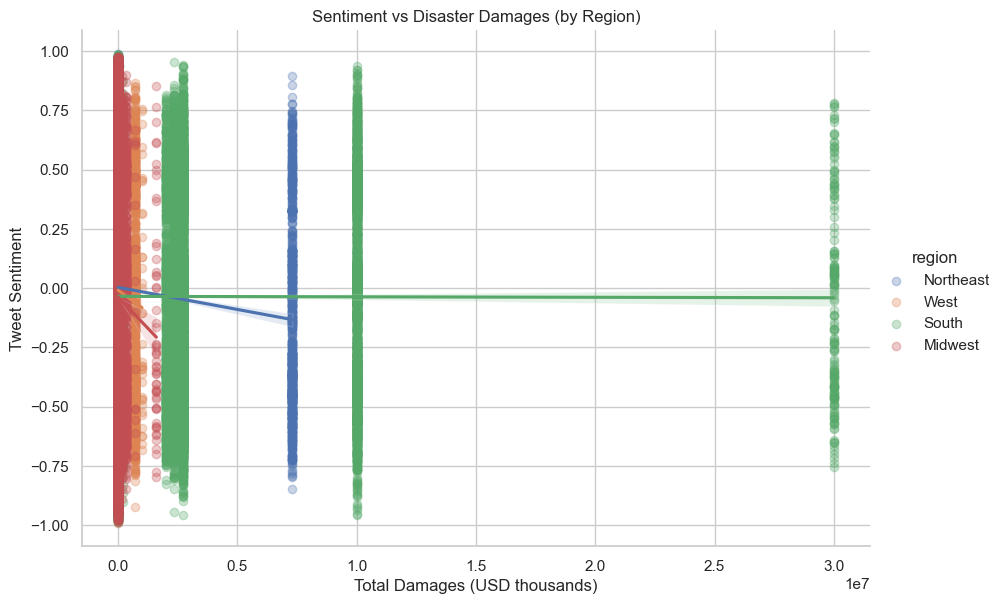

In [106]:
### SENTIMENT VS DISASTER DAMAGES ### 

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.lmplot(
    data=tweets_region,
    x='total_damages_usd',
    y='sentiment',
    hue='region',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha':0.3}
)

plt.title("Sentiment vs Disaster Damages (by Region)")
plt.xlabel("Total Damages (USD thousands)")
plt.ylabel("Tweet Sentiment")
plt.show()

Text(0.5, 1.0, 'Sentiment vs Number of Disaster Events (by Region)')

Text(0.5, 33.28125000000003, 'Number of Events')

Text(45.162968750000005, 0.5, 'Sentiment')

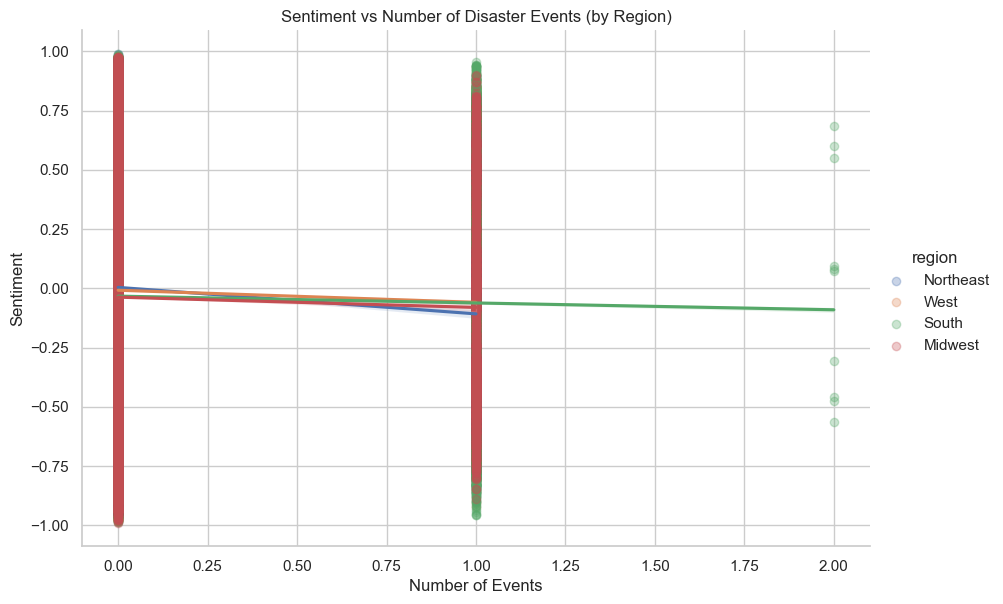

In [108]:
sns.lmplot(
    data=tweets_region,
    x='n_events',
    y='sentiment',
    hue='region',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha':0.3}
)

plt.title("Sentiment vs Number of Disaster Events (by Region)")
plt.xlabel("Number of Events")
plt.ylabel("Sentiment")
plt.show()

,region,any_disaster,sentiment
0,Midwest,0,-0.037558
1,Midwest,1,-0.080915
2,Northeast,0,0.003652
3,Northeast,1,-0.108056
4,South,0,-0.033181
5,South,1,-0.062063
6,West,0,-0.008357
7,West,1,-0.059517


<Figure size 800x600 with 0 Axes>

<Axes: xlabel='region', ylabel='sentiment'>

Text(0.5, 1.0, 'Mean Sentiment During Disaster vs. Non-Disaster Months (by Region)')

Text(0.5, 0, 'Region')

Text(0, 0.5, 'Mean Sentiment')

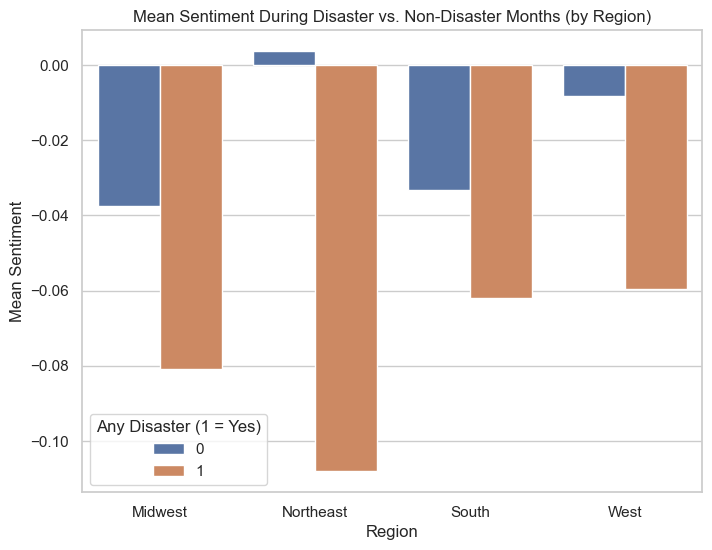

In [109]:
tweets_region['any_disaster'] = (tweets_region['n_events'] > 0).astype(int)

region_disaster_mean = (
    tweets_region
    .groupby(['region', 'any_disaster'])['sentiment']
    .mean()
    .reset_index()
)

region_disaster_mean

plt.figure(figsize=(8,6))
sns.barplot(
    data=region_disaster_mean,
    x='region',
    y='sentiment',
    hue='any_disaster'
)
plt.title("Mean Sentiment During Disaster vs. Non-Disaster Months (by Region)")
plt.xlabel("Region")
plt.ylabel("Mean Sentiment")
plt.legend(title="Any Disaster (1 = Yes)")
plt.show()

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='log_damages', ylabel='mean_sentiment'>

<Axes: xlabel='log_damages', ylabel='mean_sentiment'>

Text(0.5, 1.0, 'Region-Month Sentiment vs. Disaster Damages (log scale)')

Text(0.5, 0, 'log(1 + Total Damages)')

Text(0, 0.5, 'Mean Sentiment (region-month)')

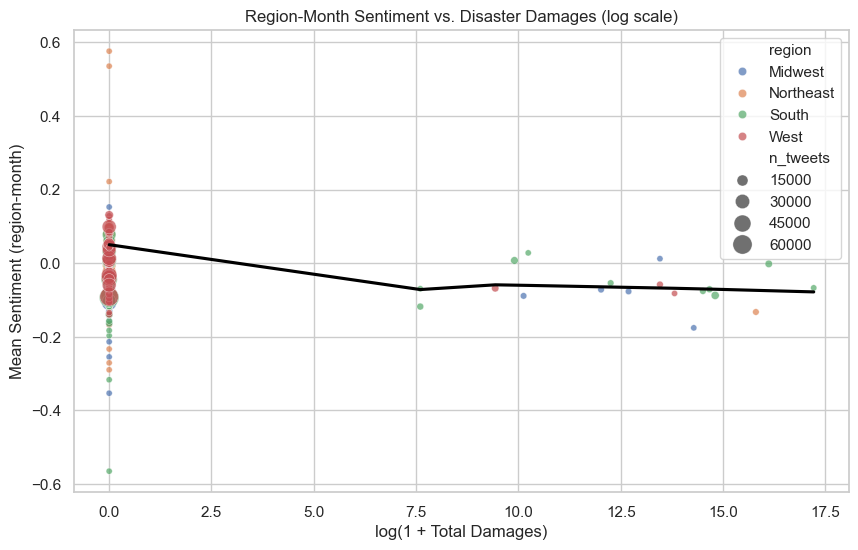

In [110]:
region_month = (
    tweets_region
    .groupby(['region','year','month'], as_index=False)
    .agg(
        mean_sentiment=('sentiment','mean'),
        n_tweets=('sentiment','size'),
        total_deaths=('total_deaths','first'),
        total_affected=('total_affected','first'),
        total_damages_usd=('total_damages_usd','first'),
        n_events=('n_events','first'),
    )
)

# add log damages for plots
region_month['log_damages'] = np.log1p(region_month['total_damages_usd'])

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=region_month,
    x='log_damages',
    y='mean_sentiment',
    hue='region',
    size='n_tweets',
    sizes=(20, 200),
    alpha=0.7
)

sns.regplot(
    data=region_month,
    x='log_damages',
    y='mean_sentiment',
    scatter=False,
    color='black',
    lowess=True
)

plt.title("Region-Month Sentiment vs. Disaster Damages (log scale)")
plt.xlabel("log(1 + Total Damages)")
plt.ylabel("Mean Sentiment (region-month)")
plt.grid(True)
plt.show()

<Figure size 900x600 with 0 Axes>

<Axes: xlabel='n_events', ylabel='mean_sentiment'>

Text(0.5, 1.0, 'Mean Sentiment by Number of Events (region-month)')

Text(0.5, 0, 'Number of disaster events in month')

Text(0, 0.5, 'Mean Sentiment')

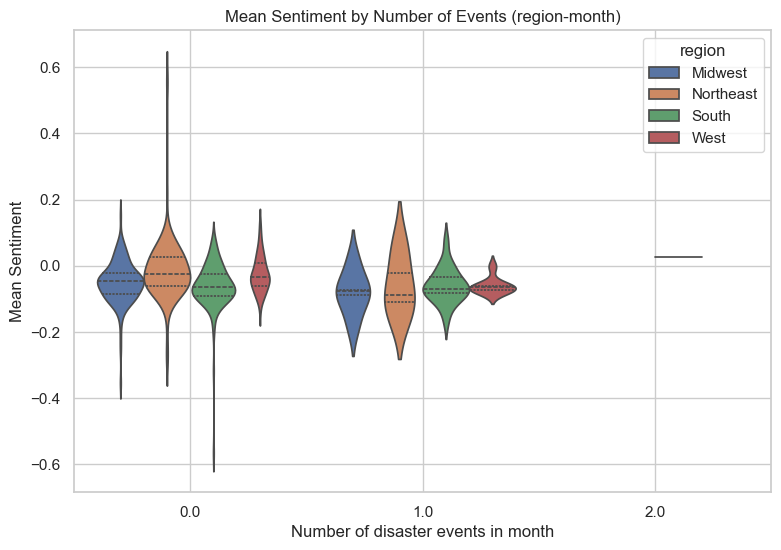

In [111]:
plt.figure(figsize=(9,6))
sns.violinplot(
    data=region_month,
    x='n_events',
    y='mean_sentiment',
    hue='region',
    split=False,
    inner='quartile'
)
plt.title("Mean Sentiment by Number of Events (region-month)")
plt.xlabel("Number of disaster events in month")
plt.ylabel("Mean Sentiment")
plt.grid(True)
plt.show()

<Figure size 900x600 with 0 Axes>

<Axes: xlabel='n_events', ylabel='mean_sentiment'>

Text(0.5, 1.0, 'Mean Sentiment by Event Count (region-month)')

Text(0.5, 0, 'Number of disaster events in month')

Text(0, 0.5, 'Mean Sentiment')

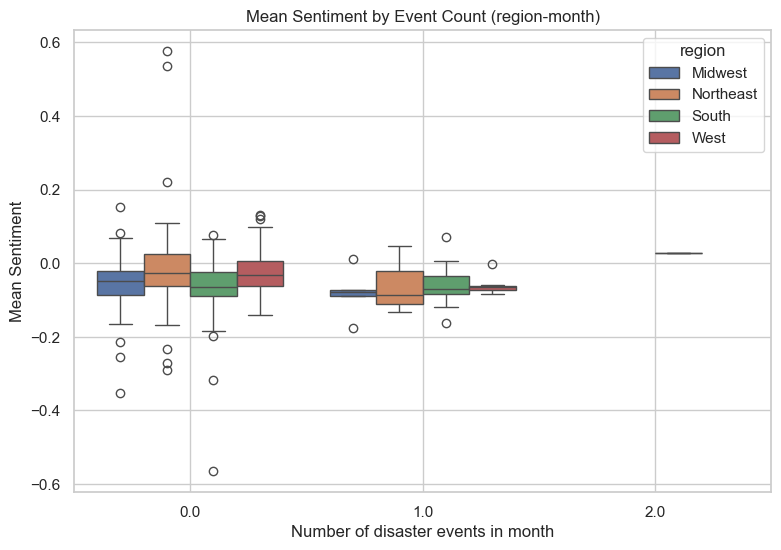

In [112]:
plt.figure(figsize=(9,6))
sns.boxplot(
    data=region_month,
    x='n_events',
    y='mean_sentiment',
    hue='region'
)
plt.title("Mean Sentiment by Event Count (region-month)")
plt.xlabel("Number of disaster events in month")
plt.ylabel("Mean Sentiment")
plt.grid(True)
plt.show()